In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("download dataset")
df = pd.read_csv('Titanic-Dataset.csv')

download dataset


In [6]:
print("The first 10 lines\n")
df.head(10)

The first 10 lines



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
print("general information\n")
df.info()

general information

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [14]:
print("description of numerical features")
df.describe()

description of numerical features


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
print("description of categorical features\n")
df.describe(include=['str', 'object'])

description of categorical features



,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [17]:
from scipy.stats import skew, kurtosis

for col in df.select_dtypes(include='number').columns:
    data = df[col].dropna()
    if len(data) > 1:
        print(f"\n {col}:")

        print(f"\tVariance (разброс): {data.var():.2f}")
        print(f"\tSkewness (асимметрия): {skew(data):.3f}")
        print(f"\tKurtosis (острота): {kurtosis(data):.3f}")


 PassengerId:
	Variance (разброс): 66231.00
	Skewness (асимметрия): 0.000
	Kurtosis (острота): -1.200

 Survived:
	Variance (разброс): 0.24
	Skewness (асимметрия): 0.478
	Kurtosis (острота): -1.772

 Pclass:
	Variance (разброс): 0.70
	Skewness (асимметрия): -0.629
	Kurtosis (острота): -1.280

 Age:
	Variance (разброс): 211.02
	Skewness (асимметрия): 0.388
	Kurtosis (острота): 0.169

 SibSp:
	Variance (разброс): 1.22
	Skewness (асимметрия): 3.689
	Kurtosis (острота): 17.774

 Parch:
	Variance (разброс): 0.65
	Skewness (асимметрия): 2.744
	Kurtosis (острота): 9.717

 Fare:
	Variance (разброс): 2469.44
	Skewness (асимметрия): 4.779
	Kurtosis (острота): 33.204


In [18]:
print("\number of objects of each class")
print(df['Survived'].value_counts())
print("\nbalance")
print(df['Survived'].value_counts(normalize=True) * 100)


umber of objects of each class
Survived
0    549
1    342
Name: count, dtype: int64

balance
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [26]:
print("missing\n")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing' : missing_count,
    'percent' : missing_percent
})

missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing',ascending=False)

print(missing_df)

missing

          missing  percent
Cabin         687    77.10
Age           177    19.87
Embarked        2     0.22


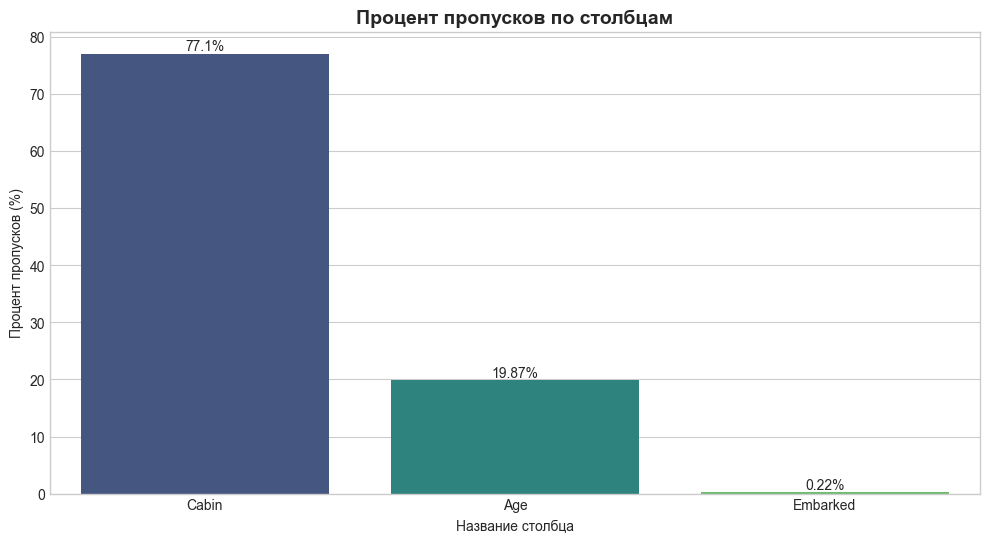

In [39]:
plt.figure(figsize=(12, 6))
#missing_df.index - названия
#palette='viridis' - раскрашиваются в зависимости от их высоты
sns.barplot(x=missing_df.index, y=missing_df['percent'], palette='viridis')
plt.title('Процент пропусков по столбцам', fontsize=14, fontweight='bold')
plt.xlabel('Название столбца')
plt.ylabel('Процент пропусков (%)')

for i, v in enumerate(missing_df['percent']):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontsize=10)

plt.show()

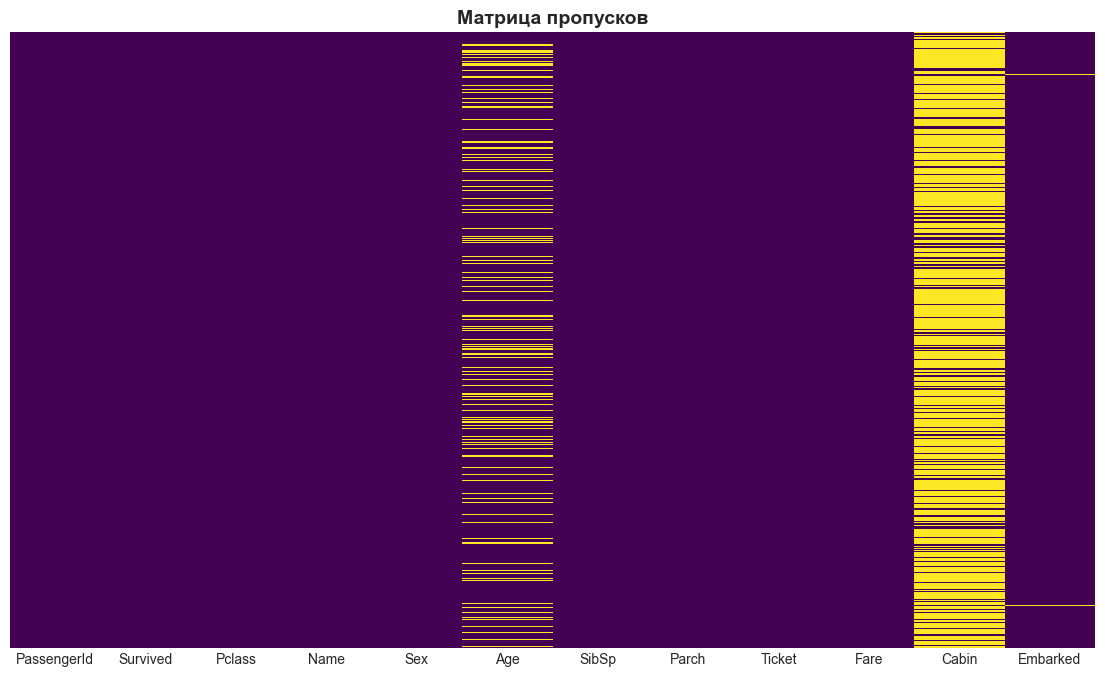

In [40]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
#cbar - отключение шкалы справа
#cmap - задает палитру
#yticklabels - скрывает индексы
plt.title('Матрица пропусков', fontsize = 14, fontweight='bold')
plt.show() 

In [48]:
#анализ целевой переменной
print(df['Survived'].value_counts())
m = df['Survived'].mean()*100
print(f"\nbalance:\n0   {(100-m):.2f}%\n1   {(m):.2f}%")

Survived
0    549
1    342
Name: count, dtype: int64

balance:
0   61.62%
1   38.38%


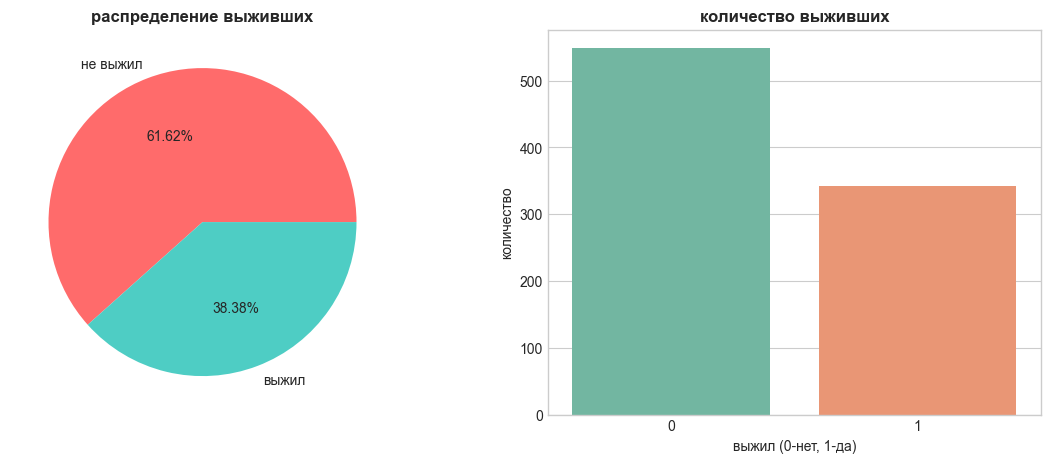

In [50]:
#создает массив из двух графиков в одной строке
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#круговая диаграмма
axes[0].pie(df['Survived'].value_counts(),
            labels=['не выжил', 'выжил'],
            autopct='%1.2f%%',
            colors=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('распределение выживших', fontsize=12, fontweight='bold')

#столбчатая диаграмма
sns.countplot(x='Survived', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('количество выживших', fontsize=12, fontweight='bold')
axes[1].set_xlabel('выжил (0-нет, 1-да)')
axes[1].set_ylabel('количество')

plt.show()

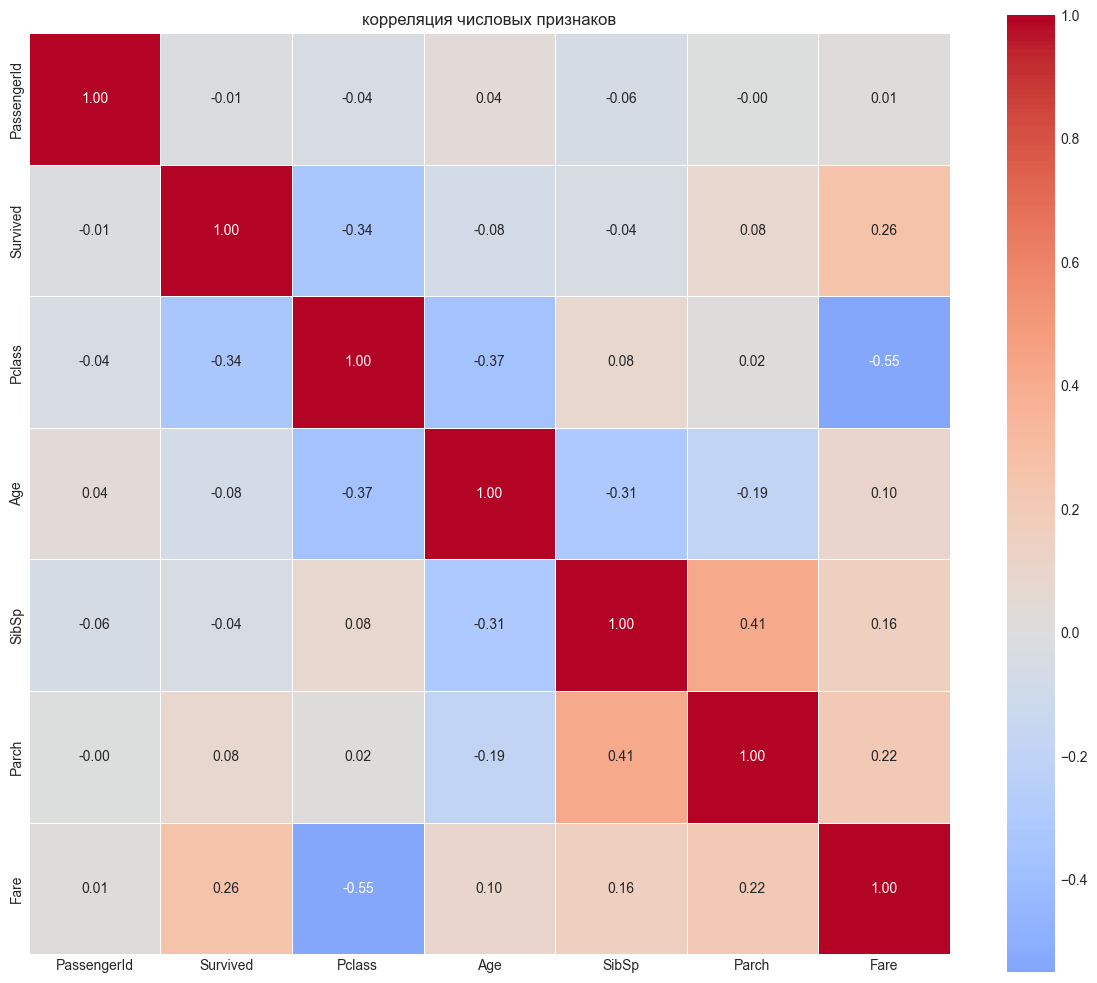

In [51]:
#корреляция признаков
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
#annot - показывать значения
#cmap - палитра
#center=0 - белый это 0, а не среднее
#square - кв ячейки
plt.title('корреляция числовых признаков')
plt.tight_layout()
plt.show()

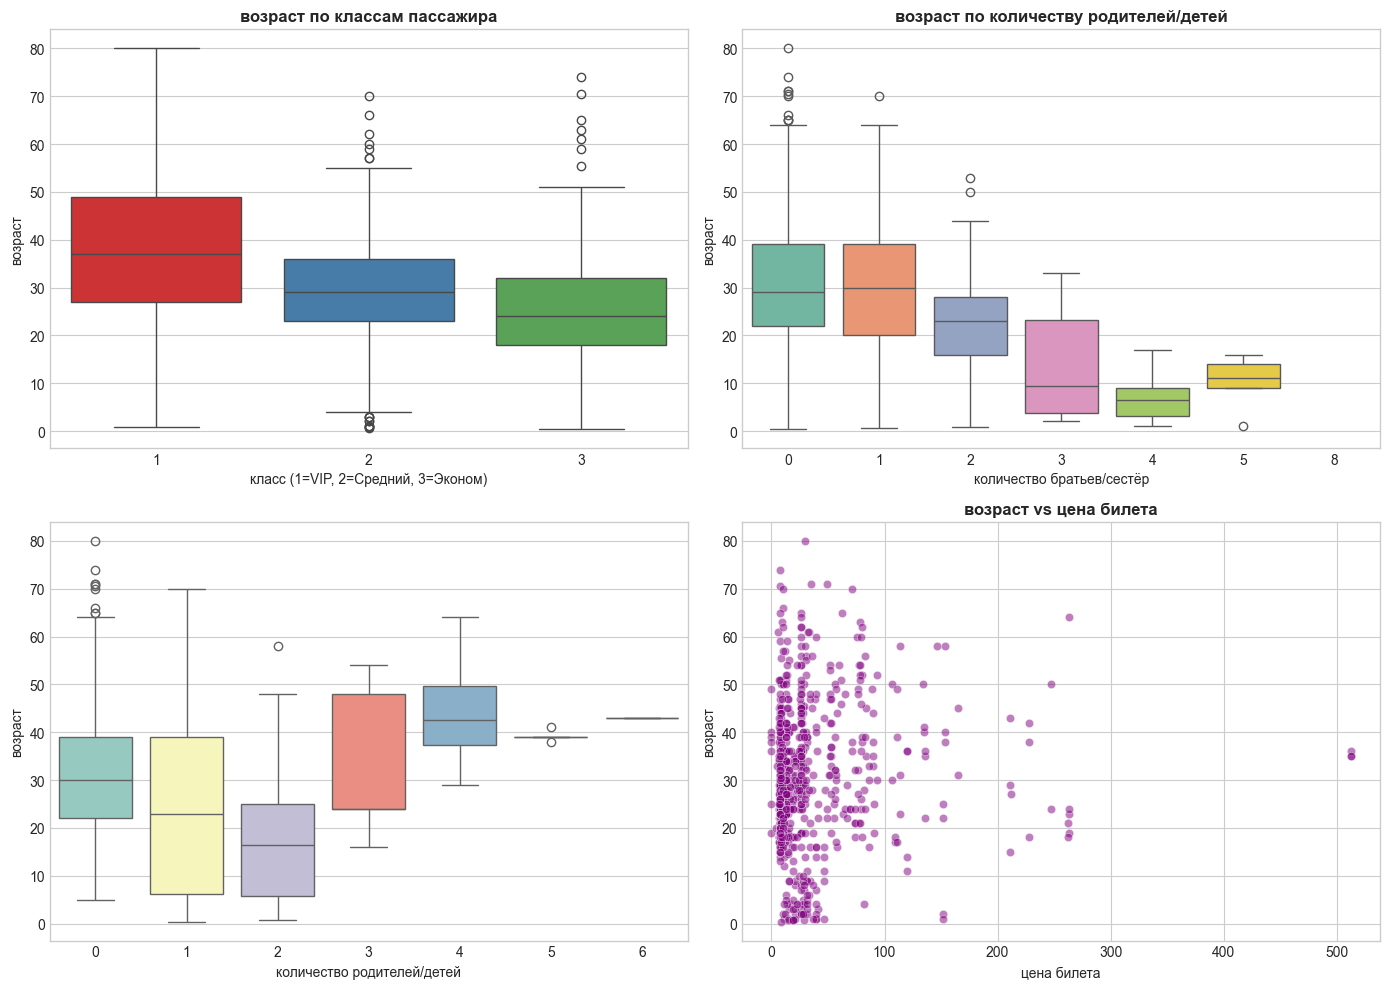

In [53]:
#анализ связи age с другими признаками
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age vs Pclass
sns.boxplot(x='Pclass', y='Age', data=df, ax=axes[0,0], palette='Set1')
axes[0,0].set_title('возраст по классам пассажира', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('класс (1=VIP, 2=Средний, 3=Эконом)')
axes[0,0].set_ylabel('возраст')

# Age vs SibSp
sns.boxplot(x='SibSp', y='Age', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('возраст по количеству братьев/сестёр', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('количество братьев/сестёр')
axes[0,1].set_ylabel('возраст')

# Age vs Parch
sns.boxplot(x='Parch', y='Age', data=df, ax=axes[1,0], palette='Set3')
axes[0,1].set_title('возраст по количеству родителей/детей', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('количество родителей/детей')
axes[1, 0].set_ylabel('возраст')

# Age vs Fare
sns.scatterplot(x='Fare', y='Age', data=df, ax=axes[1, 1], alpha=0.5, color='purple')
axes[1, 1].set_title('возраст vs цена билета', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('цена билета')
axes[1, 1].set_ylabel('возраст')

plt.tight_layout()
plt.show()

In [54]:
#преобработка

PassengerId = df['PassengerId']

df_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean = df.drop(columns=df_drop)

print(f"\nОставшиеся столбцы: {df_clean.columns.tolist()}")


Оставшиеся столбцы: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [59]:
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, random_state=42, stratify=y)

#stratify=y - сохраняем пропорцию классов в train и test

In [68]:
#обработка категориалных признаков
#заполняем Embarked, тк пропусков мало
embarked_mode = X_train['Embarked'].mode()[0]

X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

le_sex = LabelEncoder()
le_embarked = LabelEncoder()

le_sex.fit(X_train['Sex'])
X_train['Sex'] = le_sex.transform(X_train['Sex'])
X_test['Sex'] = le_sex.transform(X_test['Sex'])

le_embarked.fit(X_train['Embarked'])
X_train['Embarked'] = le_embarked.transform(X_train['Embarked'])

#находим значения в тесте, которых не было в обучении
mask_unknown = ~np.isin(X_test['Embarked'], le_embarked.classes_)
#копия и заменяем неизвестное
X_test_safe = X_test['Embarked'].copy()
X_test_safe[mask_unknown] = le_embarked.classes_[0]

X_test['Embarked'] = le_embarked.transform(X_test_safe)
X_test['Embarked'][mask_unknown] = -1

print("\ncoding of categorical features:\n")
print(f"Sex: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"Embarked: {dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_)))}")


coding of categorical features:

Sex: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Embarked: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [74]:
#масштабирование
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
#заполнение пропусков age с knn

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

X_train_imputed = knn_imputer.fit_transform(X_train_scaled)
X_test_imputed = knn_imputer.transform(X_test_scaled)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)


Age до импутации (train):
  Среднее: 0.00
  Стд. отклонение: 1.00
  Мин: -2.03
  Макс: 3.47

Age после импутации (train):
  Среднее: 0.03
  Стд. отклонение: 1.01
  Мин: -2.03
  Макс: 3.47


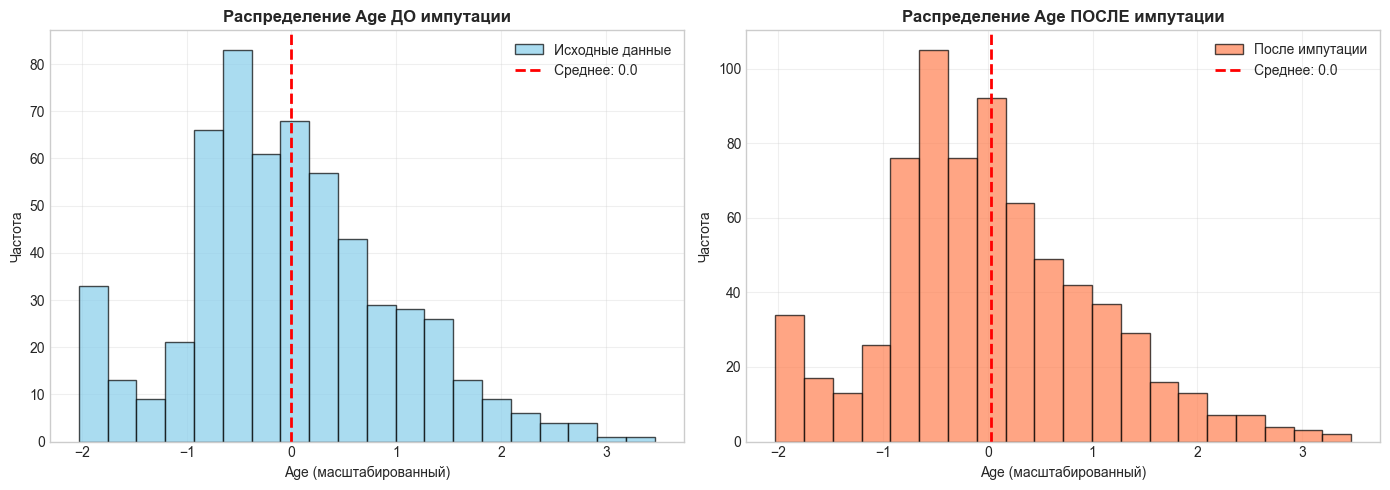

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X_train_scaled['Age'].dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black', label='Исходные данные')
axes[0].axvline(X_train_scaled['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {X_train_scaled["Age"].mean():.1f}')
axes[0].set_title('Распределение Age ДО импутации', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (масштабированный)')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(X_train_imputed['Age'], bins=20, alpha=0.7, color='coral', edgecolor='black', label='После импутации')
axes[1].axvline(X_train_imputed['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {X_train_imputed["Age"].mean():.1f}')
axes[1].set_title('Распределение Age ПОСЛЕ импутации', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age (масштабированный)')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()